In [2]:
import numpy as np
import xarray as xr
import pandas as pd
import copy
from datetime import datetime, timedelta
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import brier_score_loss
from sklearn.metrics import make_scorer
from sklearn.metrics import log_loss
from sklearn.utils.class_weight import compute_class_weight
import sys
import os
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
import glob 


from sklearn import datasets, ensemble
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import train_test_split

from sklearn.utils import class_weight
import json

import xgboost as xgb
from bayes_opt import BayesianOptimization
from bayes_opt import acquisition
import shap

In [3]:
def get_train_val_test_periods(full_df):
    dic_train_val = {}
    dic_test = {}
    
    start_of_test_periods = np.arange(1981,2021,10)
    end_of_test_periods = start_of_test_periods + 9
    
    for iperiod in range(len(start_of_test_periods)):
        df_test_temp = full_df[str(start_of_test_periods[iperiod]):str(end_of_test_periods[iperiod])]
        df_trainval_temp = full_df.drop(df_test_temp.index)
        
        dic_train_val[start_of_test_periods[iperiod]] = df_trainval_temp
        dic_test[start_of_test_periods[iperiod]] = df_test_temp
    return dic_train_val, dic_test

In [4]:

def generate_random_forecast(df_week_0, seed_value=42):
    # Set the random seed for reproducibility
    np.random.seed(seed_value)
    
    # Step 1: Get unique classes and their frequencies
    values = df_week_0[df_week_0.keys()[0]].value_counts()
    
    # Step 2: Calculate the probabilities for each class
    classes = values.index  # Unique classes
    probabilities = values / values.sum()  # Normalize to get probability distribution
    
    # Step 3: Generate a random forecast based on the probabilities
    random_forecast = np.random.choice(classes, size=len(df_week_0), p=probabilities)
    
    # Step 4: Return the random forecast as a DataFrame or Series
    forecast_df = pd.DataFrame(random_forecast, index=df_week_0.index, columns=['y_predicted'])
    
    return forecast_df

def generate_random_forecast_probabilities(df_week_0, seed_value=42):
    # Set the random seed for reproducibility
    np.random.seed(seed_value)
    # Step 1: Get unique classes and their frequencies
    values = df_week_0[df_week_0.keys()[0]].value_counts()
    
    # Step 2: Calculate the probabilities for each class
    classes = values.index  # Unique classes
    probabilities = values / values.sum()  # Normalize to get probability distribution
    
    # Step 3: Create a probability forecast for each sample
    # Create a 2D array where each row is the same probability distribution
    prob_matrix = np.tile(probabilities.values, (len(df_week_0), 1))
    
    # Step 4: Return the probability matrix as a DataFrame
    forecast_df = pd.DataFrame(prob_matrix, index=df_week_0.index, columns=classes)[np.arange(len(classes))]
    
    return forecast_df

def generate_random_forecast_with_monthly_probabilities(df_week_0, seed_value=42):
    # Set the random seed for reproducibility
    np.random.seed(seed_value)
    
    # Extract the month from the index (assuming the index is a datetime index)
    df_week_0['month'] = df_week_0.index.month
    
    # Prepare an empty list to store the random forecast
    forecasts = []
    
    # Loop through each month
    for month in range(1, 13):  # Loop through months 1 to 12
        # Filter data for the current month
        month_data = df_week_0[df_week_0['month'] == month]
        
        # Step 1: Get unique classes and their frequencies for the current month
        values = month_data[df_week_0.keys()[0]].value_counts()
        
        # Step 2: Calculate the probabilities for each class in the current month
        classes = values.index  # Unique classes
        probabilities = values / values.sum()  # Normalize to get probability distribution
        
        # Step 3: Generate random forecasts for the current month based on the probabilities
        month_forecast = np.random.choice(classes, size=len(month_data), p=probabilities)
        
        # Store the forecast for the current month
        forecasts.append(pd.Series(month_forecast, index=month_data.index))
    
    # Combine all monthly forecasts into one DataFrame
    forecast_df = pd.concat(forecasts)
    forecast_df = forecast_df.sort_index()  # Sort the index to preserve the original order
    forecast_df = pd.DataFrame(forecast_df,columns=['y_predicted'])
    return forecast_df
    
def generate_probability_forecast_with_monthly_probabilities(df_week_0, seed_value=42):
    # Set the random seed for reproducibility
    np.random.seed(seed_value)
    
    # Extract the month from the index (assuming the index is a datetime index)
    df_week_0['month'] = df_week_0.index.month
    
    # Prepare an empty DataFrame to store the probability forecasts
    all_probabilities = pd.DataFrame(index=df_week_0.index)
    
    # Loop through each month
    for month in range(1, 13):  # Loop through months 1 to 12
        # Filter data for the current month
        month_data = df_week_0[df_week_0['month'] == month]
        
        if month_data.empty:
            continue  # Skip if there's no data for the month
        
        # Step 1: Get unique classes and their frequencies for the current month
        values = month_data[df_week_0.keys()[0]].value_counts()
        
        # Step 2: Calculate the probabilities for each class in the current month
        classes = values.index  # Unique classes
        probabilities = values / values.sum()  # Normalize to get probability distribution
        
        # Step 3: Create a probability matrix for the current month
        prob_matrix = np.tile(probabilities.values, (len(month_data), 1))
        
        # Create a DataFrame for this month's probabilities with appropriate columns
        month_prob_df = pd.DataFrame(prob_matrix, index=month_data.index, columns=classes)
        
        # Append this month's DataFrame to the overall probability DataFrame
        all_probabilities = pd.concat([all_probabilities, month_prob_df])
    
    # Sort the index to match the original order
    all_probabilities = all_probabilities.sort_index()
    
    # Fill missing columns with zeros for months that do not include certain classes
    all_classes = df_week_0[df_week_0.keys()[0]].unique()
    all_probabilities = all_probabilities.reindex(columns=all_classes, fill_value=0).dropna()[np.arange(len(classes))]
    
    return all_probabilities

In [5]:
import os

# Run nvidia-smi to get GPU information
os.system('nvidia-smi')

Mon Jan 20 22:07:38 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100-SXM2-32GB           On  |   00000000:1A:00.0 Off |                    0 |
| N/A   33C    P0             90W /  300W |     514MiB /  32768MiB |     66%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

0

In [6]:
gpu_id = 6

# Extract data

In [7]:
path_wrs = '/glade/work/jhayron/Data4Predictability/WR_Series_v20241226.csv'
path_weekly_anoms = '/glade/derecho/scratch/jhayron/Data4Predictability/WeeklyAnoms_DetrendedStd_v3_2dg/'

# ### LOAD DATA WRs #####

wr_original_series = pd.read_csv(path_wrs,\
                index_col=0,names=['week0','dist'],skiprows=1,parse_dates=True)

### Do it only with the cold season ###
wr_original_series.loc[(wr_original_series.index.month<=9)&(wr_original_series.index.month>=4),'week0']=np.nan

# Rolling window for mode
rolling_mode = (
    wr_original_series.rolling('7d', center=True,min_periods=7)
    .apply(lambda x: x.mode()[0] if not x.mode().empty else float('nan'))
).shift(-3)

# Rolling window for the count of the mode
rolling_mode_count = (
    wr_original_series.rolling('7d', center=True,min_periods=7)
    .apply(lambda x: (x == x.mode()[0]).sum() if not x.mode().empty else 0)
).shift(-3)

# If duration of WR during week was less than 4, assing NO WR class
rolling_mode.loc[rolling_mode_count['week0']<4,'week0'] = 4
wr_series_mode = copy.deepcopy(rolling_mode)
time_index = pd.to_datetime(wr_series_mode.index).dayofweek
wr_series_mode = wr_series_mode.iloc[time_index.isin([0,3])].dropna()
wr_series = copy.deepcopy(wr_series_mode)

for wk in range(2,10):
    series_temp = copy.deepcopy(wr_series["week0"])
    series_temp.index = series_temp.index - timedelta(weeks = wk-1)
    series_temp.name = f'week{wk-1}'
    if wk==2:
        df_shifts = pd.concat([pd.DataFrame(wr_series["week0"]),pd.DataFrame(series_temp)],axis=1)  
    else:
        df_shifts = pd.concat([df_shifts,pd.DataFrame(series_temp)],axis=1)

list_files_anoms = np.sort(glob.glob(f'{path_weekly_anoms}*.nc'))
list_vars = [list_files_anoms[i].split('/')[-1][:-3] for i in range(len(list_files_anoms))]

for ivar in range(len(list_vars)):
    print(ivar,list_vars[ivar])

0 IC_SODA
1 IT_SODA
2 MLD_SODA
3 OHC100_SODA
4 OHC200_SODA
5 OHC300_SODA
6 OHC50_SODA
7 OHC700_SODA
8 OLR_ERA5
9 SD_ERA5
10 SSH_SODA
11 SST_OISSTv2
12 SST_SODA
13 STL_1m_ERA5
14 STL_28cm_ERA5
15 STL_7cm_ERA5
16 STL_full_ERA5
17 SWVL_1m_ERA5
18 SWVL_28cm_ERA5
19 SWVL_7cm_ERA5
20 SWVL_full_ERA5
21 U10_ERA5
22 U200_ERA5
23 Z500_ERA5


In [8]:
component = 'all'

In [9]:
indices_vars_atm = [8,21,22,23]
indices_vars_ocn = [0,1,2,3,4,5,6,7,10,12]
indices_vars_lnd = [9,13,14,15,16,17,18,19,20]
indices_vars_all = indices_vars_atm+indices_vars_ocn+indices_vars_lnd

dic_indices = {'atm':indices_vars_atm,
              'ocn':indices_vars_ocn,
              'lnd':indices_vars_lnd,
              'all':indices_vars_all}

indices_vars = dic_indices[component]

In [10]:
# Define a boxcar filter function
def boxcar_filter(data, size):
    kernel = np.ones((size, size)) / (size * size)
    from scipy.signal import convolve2d
    return convolve2d(data, kernel, mode="same", boundary="fill", fillvalue=np.nan)


In [11]:
all_dfs = []

for ivar in indices_vars:
    print(ivar,list_vars[ivar])
    path_nc_anoms = f'{path_weekly_anoms}{list_vars[ivar]}.nc'
    anoms = xr.open_dataset(path_nc_anoms)
    anoms = anoms.assign_coords(time=pd.DatetimeIndex(anoms.time).normalize())
    var_name_nc = list(anoms.data_vars.keys())[0]

    # Apply boxcar filter
    smoothed_anoms = xr.apply_ufunc(
        boxcar_filter,
        anoms,
        kwargs={"size": 3},  # Adjust window size (e.g., 5x5 grid cells)
        input_core_dims=[["lat", "lon"]],
        output_core_dims=[["lat", "lon"]],
        vectorize=True,
    )
    
    anoms_flattened = smoothed_anoms[var_name_nc].stack(flat_spatial=('lat', 'lon'))
    anoms_flattened_og = copy.deepcopy(anoms_flattened)
    anoms_flattened = pd.DataFrame(anoms_flattened,index = anoms_flattened.time)
    anoms_flattened = anoms_flattened.dropna(axis=1, how='any')
    
    combined_df = copy.deepcopy(anoms_flattened)
    all_dfs.append(combined_df)

full_df = pd.concat(all_dfs,axis=1)
full_df['day_sin'] = np.sin(2 * np.pi * full_df.index.day_of_year / 365)
full_df['day_cos'] = np.cos(2 * np.pi * full_df.index.day_of_year / 365)

8 OLR_ERA5
21 U10_ERA5
22 U200_ERA5
23 Z500_ERA5
0 IC_SODA
1 IT_SODA
2 MLD_SODA
3 OHC100_SODA
4 OHC200_SODA
5 OHC300_SODA
6 OHC50_SODA
7 OHC700_SODA
10 SSH_SODA
12 SST_SODA
9 SD_ERA5
13 STL_1m_ERA5
14 STL_28cm_ERA5
15 STL_7cm_ERA5
16 STL_full_ERA5
17 SWVL_1m_ERA5
18 SWVL_28cm_ERA5
19 SWVL_7cm_ERA5
20 SWVL_full_ERA5


In [12]:
def brier_multi(targets, probs):
    return np.mean(np.sum((probs - targets)**2, axis=1))

In [13]:
def is_dominated(candidate, others):
    """
    Checks if a candidate is dominated by any other combination in the list.
    """
    for other in others:
        if all(o >= c for c, o in zip(candidate, other)) and any(o > c for c, o in zip(candidate, other)):
            return True
    return False

In [14]:
from sklearn.model_selection import StratifiedKFold, KFold

for week_out in [1,2,3,4]:
    start_time = datetime.now()
    print(f'WEEK: {week_out}')
    week_out_str = f'week{week_out}'
    
    fully_combined_df = pd.concat([full_df,df_shifts[week_out_str]],axis=1)
    fully_combined_df = fully_combined_df.dropna()
    
    # Step 1: Split the data into training+validation and testing sets
    trainval_df, test_df = train_test_split(fully_combined_df, test_size=0.25, shuffle=False)
    
    kf = KFold(n_splits=3, shuffle=False)
    
    X_trainval = trainval_df.iloc[:,:-1]
    y_trainval = trainval_df.iloc[:,-1]
    
    X_test = test_df.iloc[:,:-1]
    y_test = test_df.iloc[:,-1]
    
    folds = []
    for train_index, val_index in kf.split(X_trainval, y_trainval):
        folds.append((train_index, val_index))

    import random
    # Set the seed for reproducibility
    seed_value = 0
    random.seed(seed_value)
    np.random.seed(seed_value)
    # Function to randomly sample from the bounds
    def random_sample_hyperparams(pbounds, n_samples):
        sampled_params = []
        for _ in range(n_samples):
            params = {}
            for key, (low, high) in pbounds.items():
                if 'log10' in key:  # Log-scale sampling
                    params[key] = 10 ** random.uniform(low, high)
                elif isinstance(low, int) and isinstance(high, int):  # Integer sampling
                    params[key] = random.randint(low, high)
                else:  # Continuous sampling
                    params[key] = random.uniform(low, high)
            sampled_params.append(params)
        return sampled_params
    
    # Define the bounds for the hyperparameters
    pbounds = {
        'max_depth': (2, 30),  # Tree depth
        'min_child_weight': (1, 20),  # Minimum sum of instance weights in a leaf
        'subsample': (0.7, 0.9),  # Subsample ratio of training data
        'colsample_bytree': (0.05, 1),  # Feature sampling per tree
        'colsample_bylevel': (0.05, 1),  # Feature sampling per level
        
        'log10_learning_rate': (-3, -0.3),  # Log10 space for learning rate
        'gamma': (0, 20.),  # Regularization term
        'log10_reg_lambda': (0, 2.5),  # L2 regularization (log-scale)
        'log10_reg_alpha': (0, 1.6),  # L1 regularization (log-scale)
        'log10_n_trees': (1., 2.5),  # L1 regularization (log-scale)
        'beta_class_weights': (0., 5.),  # 
    }
    
    # Example: Generate 10 random hyperparameter combinations
    n_samples = 300
    random_params = random_sample_hyperparams(pbounds, n_samples)
    
    # # Print the generated hyperparameter combinations
    # for i, params in enumerate(random_params):
    #     print(f"Sample {i+1}: {params}")
    import datetime as dt
    print(dt.datetime.now())
    
    scores_full = []
    for ifold in range(len(folds)):
        X_train_fold = X_trainval.iloc[folds[ifold][0]]
        y_train_fold = y_trainval.iloc[folds[ifold][0]]
    
        X_test_fold = X_trainval.iloc[folds[ifold][1]]
        y_test_fold = y_trainval.iloc[folds[ifold][1]]
    
        dtrain_fold = xgb.DMatrix(X_train_fold.values, y_train_fold.values)
        dtest_fold = xgb.DMatrix(X_test_fold.values, y_test_fold.values)
        
        scores_fold = []
        for iparams,params_temp in enumerate(random_params):
            beta_class_weights = params_temp['beta_class_weights']
            class_weights_arr = compute_class_weight('balanced', 
                                                     classes=np.unique(y_train_fold), y=y_train_fold)
            class_weight_dict = dict(zip(np.unique(y_train_fold), class_weights_arr))
            train_weight = np.array([class_weight_dict[label] for label in y_train_fold])**beta_class_weights
            dtrain_fold.set_weight(train_weight)
            
            clf = xgb.XGBClassifier(
                max_depth = params_temp['max_depth'],               # Limit tree depth to avoid overfitting.
                learning_rate = params_temp['log10_learning_rate'],        # Smaller learning rate for stable learning.
                subsample = params_temp['subsample'],             # Use 80% of the training data for each boosting round.
                colsample_bytree = params_temp['colsample_bytree'],      # Use 10% of features for each tree to handle high dimensionality.
                colsample_bylevel = params_temp['colsample_bylevel'],     # Use 10% of features at each level (to reduce computation and avoid overfitting).
                gamma = params_temp['gamma'],                      # Penalize overly complex trees.
                min_child_weight = params_temp['min_child_weight'],# Minimum sum of instance weights in a leaf to prevent small splits.
                reg_alpha = params_temp['log10_reg_alpha'],              # L1 regularization for sparsity in feature selection.
                reg_lambda = params_temp['log10_reg_lambda'],            # L2 regularization to control large weights and prevent overfitting.
                num_class=5,
                objective = "multi:softprob",
                tree_method='hist',
                device = f'cuda:{gpu_id}')
            dic_params_cv = clf.get_xgb_params()
            ### Train model ###
            clf = xgb.train(
                            dic_params_cv,
                            dtrain_fold,
                            num_boost_round=int(params_temp['log10_n_trees'])  # Use the best boosting rounds
                            )
            ### Evaluate ###
            preds = clf.predict(dtest_fold)
            targets = y_test_fold
            y_one_hot = np.eye(5)[targets.values.astype(int)]
            f1_score_micro = f1_score(targets, np.argmax(preds, axis=1), average='micro')  # Use your chosen metric
            f1_score_macro = f1_score(targets, np.argmax(preds, axis=1), average='macro')  # Use your chosen metric
            f1_score_weighted = f1_score(targets, np.argmax(preds, axis=1), average='weighted')  # Use your chosen metric
            brier_score = brier_multi(y_one_hot, preds)
    
            scores_temp = [f1_score_micro,f1_score_macro,f1_score_weighted,brier_score]
            scores_fold.append(scores_temp)
        scores_full.append(scores_fold)
    
    print(dt.datetime.now())
    scores_full = np.array(scores_full)
    scores_average_folds = scores_full.mean(axis=0)
    # Change sign of Brier score
    scores_average_folds[:,-1] = -scores_average_folds[:,-1]
    print(scores_average_folds.argmax(axis=0))
    print(scores_average_folds.max(axis=0))
    from sklearn.preprocessing import MinMaxScaler
    
    # Normalize the scores
    scaler = MinMaxScaler()
    normalized_scores = scaler.fit_transform(scores_average_folds)

    # Find the indices of the Pareto frontier
    pareto_indices = []
    for i, score in enumerate(normalized_scores):
        # Remove the current score and check if it's dominated by others
        others = np.delete(normalized_scores, i, axis=0)
        if not is_dominated(score, others):
            pareto_indices.append(i)
    
    # Get the Pareto frontier combinations and their original scores
    pareto_frontier = normalized_scores[pareto_indices]
    pareto_original_scores = scores_average_folds[pareto_indices]

    avg_norm_scores = []
    for p_index in pareto_indices:
        print(normalized_scores[p_index])
        avg_norm_scores.append(normalized_scores[p_index].mean())
    print(np.argmax(avg_norm_scores))
    best_params = random_params[pareto_indices[np.argmax(avg_norm_scores)]]

    clf = xgb.XGBClassifier(
        max_depth = best_params['max_depth'],               # Limit tree depth to avoid overfitting.
        learning_rate = best_params['log10_learning_rate'],        # Smaller learning rate for stable learning.
        subsample = best_params['subsample'],             # Use 80% of the training data for each boosting round.
        colsample_bytree = best_params['colsample_bytree'],      # Use 10% of features for each tree to handle high dimensionality.
        colsample_bylevel = best_params['colsample_bylevel'],     # Use 10% of features at each level (to reduce computation and avoid overfitting).
        gamma = best_params['gamma'],                      # Penalize overly complex trees.
        min_child_weight = best_params['min_child_weight'],# Minimum sum of instance weights in a leaf to prevent small splits.
        reg_alpha = best_params['log10_reg_alpha'],              # L1 regularization for sparsity in feature selection.
        reg_lambda = best_params['log10_reg_lambda'],            # L2 regularization to control large weights and prevent overfitting.
        num_class=5,
        objective = "multi:softprob",
        tree_method='hist',
        device = f'cuda:{gpu_id}')
    dic_params_cv = clf.get_xgb_params()
    
    ### Train model ###
    beta_class_weights = best_params['beta_class_weights']
    class_weights_arr = compute_class_weight('balanced', 
                                             classes=np.unique(y_trainval), y=y_trainval)
    class_weight_dict = dict(zip(np.unique(y_trainval), class_weights_arr))
    train_weight = np.array([class_weight_dict[label] for label in y_trainval])**beta_class_weights
    
    dtrain = xgb.DMatrix(X_trainval.values, y_trainval.values, weight=train_weight)
    dtest = xgb.DMatrix(X_test.values, y_test.values)
    clf = xgb.train(
                    dic_params_cv,
                    dtrain,
                    num_boost_round=int(best_params['log10_n_trees'])  
                    )

    ### Evaluate ###
    preds = clf.predict(dtest)
    targets = y_test
    df_results = pd.DataFrame(np.array([targets.values,np.argmax(preds, axis=1)]).T,
                 index=targets.index,columns=['y_true','y_predicted'])
    
    df_probabilities = pd.DataFrame(preds,
                 index=targets.index)

    metrics_iterations = []
    for _ in range(1000):  # Adjust the number of iterations as needed
        sample_indices = np.random.choice(df_results.index, size=int(len(df_results)), replace=True)
        results_temp = df_results.loc[sample_indices]
        probs_temp = df_probabilities.loc[sample_indices]
        
        preds = probs_temp.values
        targets = results_temp['y_true']
        preds_vals = results_temp['y_predicted']
        y_one_hot = np.eye(5)[targets.values.astype(int)]
        f1_score_micro = f1_score(targets, preds_vals, average='micro')  # Use your chosen metric
        f1_score_macro = f1_score(targets, preds_vals, average='macro')  # Use your chosen metric
        f1_score_weighted = f1_score(targets, preds_vals, average='weighted')  # Use your chosen metric
        brier_score = brier_multi(y_one_hot, preds)
    
        metrics_iterations.append([f1_score_micro,f1_score_macro,f1_score_weighted,brier_score])
    metrics_iterations = np.array(metrics_iterations)

    ### Evaluate ###
    preds = clf.predict(dtest)
    targets = y_test
    y_one_hot = np.eye(5)[targets.values.astype(int)]
    f1_score_micro = f1_score(targets, np.argmax(preds, axis=1), average='micro')  # Use your chosen metric
    f1_score_macro = f1_score(targets, np.argmax(preds, axis=1), average='macro')  # Use your chosen metric
    f1_score_weighted = f1_score(targets, np.argmax(preds, axis=1), average='weighted')  # Use your chosen metric
    brier_score = brier_multi(y_one_hot, preds)
    
    print('***Metrics without XAI:***')
    print('F1 Micro|F1 Macro|F1 Weighted|Brier Score')
    print([f1_score_micro,f1_score_macro,f1_score_weighted,brier_score])
    
    print('Upper bound of 90% confidence interval:')
    print(np.quantile(metrics_iterations,0.95,axis=0))
    print('Lower bound of 90% confidence interval:')
    print(np.quantile(metrics_iterations,0.05,axis=0))

    np.save(f'ResultsControl/{week_out_str}_best_params.npy',best_params)
    np.save(f'ResultsControl/{week_out_str}_scores_full.npy',scores_full)
    np.save(f'ResultsControl/{week_out_str}_random_params.npy',random_params)
    np.save(f'ResultsControl/{week_out_str}_metrics_iterations.npy',metrics_iterations)
    df_results.to_csv(f'ResultsControl/{week_out_str}_df_results.csv')
    df_probabilities.to_csv(f'ResultsControl/{week_out_str}_df_probabilities.csv')

WEEK: 1
2025-01-20 22:08:48.969398
2025-01-21 00:37:44.670166
[173 115 173 243]
[ 0.39787092  0.35407123  0.37270022 -0.72514512]
[0.89438202 0.95173119 0.94058354 0.90397191]
[0.91685393 0.88267919 0.94498354 0.98259003]
[0.87640449 0.9483651  0.93874713 0.93090094]
[0.91910112 0.95437127 0.95723654 0.89026386]
[0.93033708 0.98017886 0.98152461 0.83347075]
[0.9258427  0.94344042 0.95122541 0.91534949]
[0.97078652 0.88342788 0.93508266 0.8855778 ]
[0.92808989 0.93785329 0.95056865 0.85515772]
[0.93707865 1.         0.98093863 0.73448884]
[1.         0.99857675 1.         0.80784429]
[0.93707865 0.93816319 0.93512963 0.8723423 ]
[0.93707865 0.98348048 0.97162826 0.82486876]
[0.94382022 0.85436282 0.9383339  1.        ]
[0.95280899 0.91158885 0.96881322 0.81699327]
[0.87191011 0.93663013 0.95227983 0.95576954]
9
***Metrics without XAI:***
F1 Micro|F1 Macro|F1 Weighted|Brier Score
[0.38323353293413176, 0.3426267025028635, 0.36960370416924804, 0.7720720034936136]
Upper bound of 90% confide

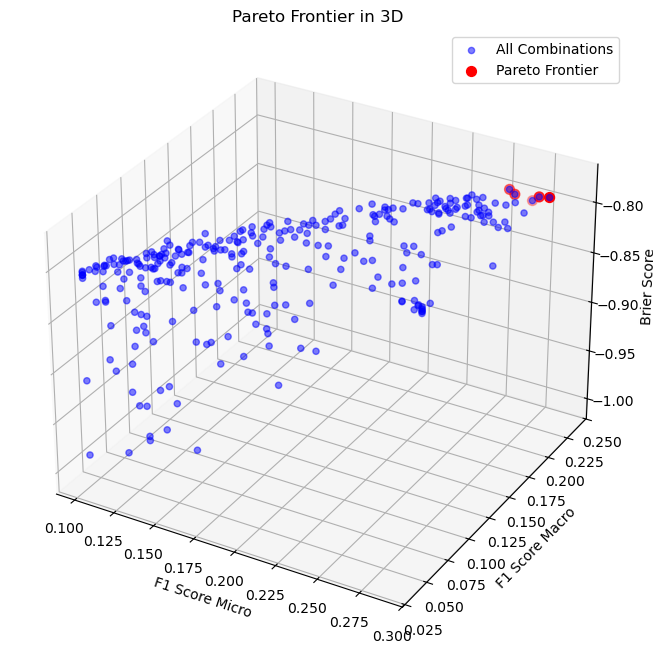

In [21]:
# from mpl_toolkits.mplot3d import Axes3D
# import matplotlib.pyplot as plt

# # Extract specific metrics for 3D visualization
# f1_micro = scores_average_folds[:, 0]
# f1_macro = scores_average_folds[:, 1]
# brier_score = scores_average_folds[:, 3]

# # Pareto frontier values for these metrics
# pareto_f1_micro = pareto_original_scores[:, 0]
# pareto_f1_macro = pareto_original_scores[:, 1]
# pareto_brier_score = pareto_original_scores[:, 3]

# # Create a 3D scatterplot
# fig = plt.figure(figsize=(10, 8))
# ax = fig.add_subplot(111, projection='3d')

# # Scatter plot of all combinations
# ax.scatter(f1_micro, f1_macro, brier_score, c='blue', alpha=0.5, label="All Combinations")

# # Highlight the Pareto frontier
# ax.scatter(pareto_f1_micro, pareto_f1_macro, pareto_brier_score, c='red', s=50, label="Pareto Frontier")

# # Add labels and title
# ax.set_xlabel("F1 Score Micro")
# ax.set_ylabel("F1 Score Macro")
# ax.set_zlabel("Brier Score")
# ax.set_title("Pareto Frontier in 3D")
# ax.legend()

# # Show the plot
# plt.show()

[0.95683453 0.93309725 0.99761104 0.97483954]
[0.85611511 0.94250206 0.95426663 0.96659917]
[0.87769784 0.93477208 0.94726617 0.95757752]
[1.         0.91210977 0.98520275 1.        ]
[0.9028777  1.         1.         0.89913371]
3


In [43]:
print(f1_score_micro,f1_score_macro,f1_score_weighted,brier_score)

0.25948103792415167 0.19852136949138174 0.22008849524506707 0.7946687570617514


In [44]:
best_params

{'max_depth': 2,
 'min_child_weight': 10,
 'subsample': 0.830581242206494,
 'colsample_bytree': 0.2516836560319482,
 'colsample_bylevel': 0.13468896905277844,
 'log10_learning_rate': 0.08836102800952758,
 'gamma': 4.957143496365206,
 'log10_reg_lambda': 20.287290088247364,
 'log10_reg_alpha': 5.306004248443237,
 'log10_n_trees': 289.15041187902807,
 'beta_class_weights': 0.053407354847205823}

In [45]:
np.bincount(np.argmax(preds, axis=1))

array([235,  85,  58,   0, 123])

In [46]:
np.bincount(targets)

array([117, 143,  82,  67,  92])

In [40]:
# ### Evaluate ###
# preds = clf.predict(dtrain)
# targets = y_trainval
# y_one_hot = np.eye(5)[targets.values.astype(int)]
# f1_score_micro = f1_score(targets, np.argmax(preds, axis=1), average='micro')  # Use your chosen metric
# f1_score_macro = f1_score(targets, np.argmax(preds, axis=1), average='macro')  # Use your chosen metric
# f1_score_weighted = f1_score(targets, np.argmax(preds, axis=1), average='weighted')  # Use your chosen metric
# brier_score = brier_multi(y_one_hot, preds)
# print(f1_score_micro,f1_score_macro,f1_score_weighted,brier_score)
# np.bincount(np.argmax(preds, axis=1))
# np.bincount(targets)

# Compute confidence interval for each metric

In [59]:
### Evaluate ###
preds = clf.predict(dtest)
targets = y_test
y_one_hot = np.eye(5)[targets.values.astype(int)]
f1_score_micro = f1_score(targets, np.argmax(preds, axis=1), average='micro')  # Use your chosen metric
f1_score_macro = f1_score(targets, np.argmax(preds, axis=1), average='macro')  # Use your chosen metric
f1_score_weighted = f1_score(targets, np.argmax(preds, axis=1), average='weighted')  # Use your chosen metric
brier_score = brier_multi(y_one_hot, preds)

In [73]:
### Evaluate ###
preds = clf.predict(dtest)
targets = y_test
y_one_hot = np.eye(5)[targets.values.astype(int)]
f1_score_micro = f1_score(targets, np.argmax(preds, axis=1), average='micro')  # Use your chosen metric
f1_score_macro = f1_score(targets, np.argmax(preds, axis=1), average='macro')  # Use your chosen metric
f1_score_weighted = f1_score(targets, np.argmax(preds, axis=1), average='weighted')  # Use your chosen metric
brier_score = brier_multi(y_one_hot, preds)

print('***Metrics without XAI:***')
print('F1 Micro|F1 Macro|F1 Weighted|Brier Score')
print([f1_score_micro,f1_score_macro,f1_score_weighted,brier_score])

print('Upper bound of 90% confidence interval:')
print(np.quantile(metrics_iterations,0.95,axis=0))
print('Lower bound of 90% confidence interval:')
print(np.quantile(metrics_iterations,0.05,axis=0))

***Metrics without XAI:***
F1 Micro|F1 Macro|F1 Weighted|Brier Score
[0.25948103792415167, 0.19852136949138174, 0.22008849524506707, 0.7946687570617514]
Upper bound of 90% confidence interval:
[0.29141717 0.22354096 0.25187515 0.80796365]
Lower bound of 90% confidence interval:
[0.22954092 0.17184838 0.18982361 0.78249251]
